# Notebook 3: VADER Baseline Model
## Boris Letić (E2 126/2025) | Bitcoin Sentiment Analysis

**Purpose:** Establish baseline performance with rule-based sentiment analysis

**Models:**
1. VADER Simple (direct classification)
2. VADER + Logistic Regression (ML enhancement)

**Output:** Baseline metrics to compare against deep learning models

## 1. Setup

In [23]:
import pandas as pd
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
import os
import json

warnings.filterwarnings('ignore')
tqdm.pandas()
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

print("✓ Setup complete")

✓ Setup complete


## 2. Load Data

In [24]:
df = pd.read_csv('data/processed/tweets_preprocessed.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
print(f"✓ Loaded {len(df):,} tweets")

✓ Loaded 11,120 tweets


## 3. Train/Test Split (80/20)

In [25]:
df = df.sort_values('datetime').reset_index(drop=True)
split = int(len(df) * 0.8)
train = df.iloc[:split].copy()
test = df.iloc[split:].copy()

print(f"Train: {len(train):,} | Test: {len(test):,}")
print(f"Train: {train['datetime'].min().date()} to {train['datetime'].max().date()}")
print(f"Test:  {test['datetime'].min().date()} to {test['datetime'].max().date()}")

Train: 8,896 | Test: 2,224
Train: 2024-01-01 to 2024-04-23
Test:  2024-04-23 to 2024-05-31


## 4. VADER Simple Baseline

In [26]:
vader = SentimentIntensityAnalyzer()

def vader_classify(text):
    if pd.isna(text) or text == "": return 'neutral'
    compound = vader.polarity_scores(text)['compound']
    if compound >= 0.05: return 'positive'
    elif compound <= -0.05: return 'negative'
    else: return 'neutral'

print("Applying VADER to test set...")
test['vader_pred'] = test['text_cleaned'].progress_apply(vader_classify)
test['vader_compound'] = test['text_cleaned'].progress_apply(
    lambda x: vader.polarity_scores(x)['compound'] if pd.notna(x) and x else 0.0
)
print("✓ VADER predictions complete")

Applying VADER to test set...


100%|██████████| 2224/2224 [00:00<00:00, 64956.88it/s]

✓ VADER predictions complete


## 5. VADER Simple - Evaluation

In [27]:
y_true = test['sentiment'].values
y_pred_vader = test['vader_pred'].values

vader_acc = accuracy_score(y_true, y_pred_vader)
vader_f1 = f1_score(y_true, y_pred_vader, average='weighted')

print(f"VADER Simple:")
print(f"  Accuracy: {vader_acc:.4f} ({vader_acc*100:.2f}%)")
print(f"  F1-Score: {vader_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred_vader, digits=4))

cm_vader = confusion_matrix(y_true, y_pred_vader, labels=['positive','neutral','negative'])
print(f"\nConfusion Matrix:")
print(cm_vader)

VADER Simple:
  Accuracy: 0.4078 (40.78%)
  F1-Score: 0.4114

Classification Report:
              precision    recall  f1-score   support

    negative     0.2912    0.4649    0.3581       228
     neutral     0.4989    0.3872    0.4360      1139
    positive     0.3689    0.4201    0.3928       857

    accuracy                         0.4078      2224
   macro avg     0.3863    0.4241    0.3956      2224
weighted avg     0.4275    0.4078    0.4114      2224


Confusion Matrix:
[[360 359 138]
 [578 441 120]
 [ 38  84 106]]


## 6. VADER + Logistic Regression

In [28]:
def get_vader_features(text):
    if pd.isna(text) or text == "": return {'pos':0,'neg':0,'neu':1,'compound':0}
    return vader.polarity_scores(text)

print("Extracting VADER features...")
train_feats = pd.DataFrame(train['text_cleaned'].progress_apply(get_vader_features).tolist())
test_feats = pd.DataFrame(test['text_cleaned'].progress_apply(get_vader_features).tolist())

label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
y_train = train['sentiment'].map(label_map).values
y_test = test['sentiment'].map(label_map).values

scaler = StandardScaler()
X_train = scaler.fit_transform(train_feats.values)
X_test = scaler.transform(test_feats.values)

print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
label_inv = {v:k for k,v in label_map.items()}
y_pred_lr_labels = np.array([label_inv[p] for p in y_pred_lr])

print("✓ VADER + LR complete")

Extracting VADER features...


100%|██████████| 2224/2224 [00:00<00:00, 64618.50it/s]

Training Logistic Regression...
✓ VADER + LR complete


## 7. VADER + LR - Evaluation

In [29]:
lr_acc = accuracy_score(y_true, y_pred_lr_labels)
lr_f1 = f1_score(y_true, y_pred_lr_labels, average='weighted')

print(f"VADER + Logistic Regression:")
print(f"  Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)")
print(f"  F1-Score: {lr_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred_lr_labels, digits=4))

cm_lr = confusion_matrix(y_true, y_pred_lr_labels, labels=['positive','neutral','negative'])
print(f"\nConfusion Matrix:")
print(cm_lr)

VADER + Logistic Regression:
  Accuracy: 0.5607 (56.07%)
  F1-Score: 0.5521

Classification Report:
              precision    recall  f1-score   support

    negative     0.2888    0.4649    0.3563       228
     neutral     0.6207    0.7384    0.6744      1139
    positive     0.5976    0.3501    0.4415       857

    accuracy                         0.5607      2224
   macro avg     0.5024    0.5178    0.4907      2224
weighted avg     0.5778    0.5607    0.5521      2224


Confusion Matrix:
[[300 418 139]
 [176 841 122]
 [ 26  96 106]]


## 8. Model Comparison

In [30]:
comparison = pd.DataFrame({
    'Model': ['VADER Simple', 'VADER + LR'],
    'Accuracy': [vader_acc, lr_acc],
    'F1-Score': [vader_f1, lr_f1]
})

print(comparison.to_string(index=False))
print(f"\nBest: {'VADER + LR' if lr_acc > vader_acc else 'VADER Simple'}")
print(f"Improvement: {abs(lr_acc - vader_acc)*100:.2f} pp")

       Model  Accuracy  F1-Score
VADER Simple  0.407824  0.411360
  VADER + LR  0.560701  0.552053

Best: VADER + LR
Improvement: 15.29 pp


## 9. Confusion Matrices

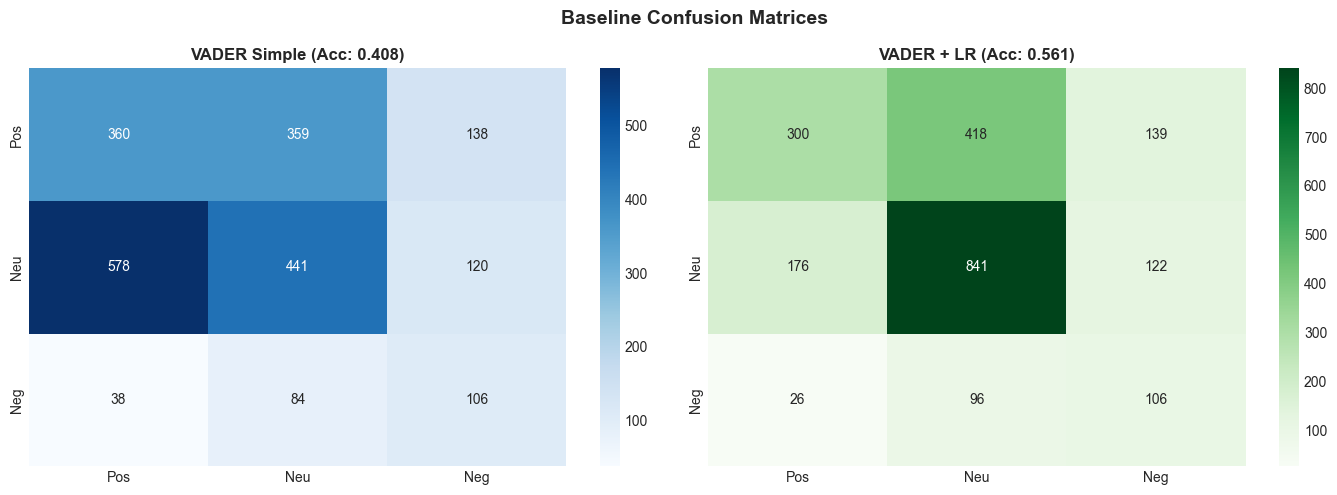

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_vader, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pos','Neu','Neg'], yticklabels=['Pos','Neu','Neg'],
            ax=axes[0])
axes[0].set_title(f'VADER Simple (Acc: {vader_acc:.3f})', fontweight='bold')

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pos','Neu','Neg'], yticklabels=['Pos','Neu','Neg'],
            ax=axes[1])
axes[1].set_title(f'VADER + LR (Acc: {lr_acc:.3f})', fontweight='bold')

plt.suptitle('Baseline Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Error Analysis

In [32]:
test['lr_pred'] = y_pred_lr_labels
errors = test[test['sentiment'] != test['lr_pred']].copy()

print(f"Total errors: {len(errors):,} / {len(test):,} ({len(errors)/len(test)*100:.2f}%)")
print(f"\nTop 5 misclassifications:")
for i, (idx, row) in enumerate(errors.head(5).iterrows()):
    print(f"\n[{i+1}] True: {row['sentiment']} | Pred: {row['lr_pred']}")
    print(f"    VADER: {row['vader_compound']:+.3f}")
    print(f"    Text: {row['text_cleaned'][:70]}...")

Total errors: 977 / 2,224 (43.93%)

Top 5 misclassifications:

[1] True: neutral | Pred: negative
    VADER: -0.340
    Text: bitcoin mining difficulty adjustment coming up thinking at...

[2] True: positive | Pred: neutral
    VADER: +0.000
    Text: not selling until we hit six figures btc...

[3] True: positive | Pred: neutral
    VADER: +0.000
    Text: this is just the beginning for bitcoin thoughts...

[4] True: neutral | Pred: positive
    VADER: +0.402
    Text: interesting price action on bitcoin today bitcoin price...

[5] True: neutral | Pred: negative
    VADER: -0.250
    Text: bitcoin chart looking indecisive right now at...


## 11. Export Results

In [33]:
os.makedirs('results/baseline', exist_ok=True)

# Save predictions
test[['datetime','text','sentiment','vader_pred','vader_compound','lr_pred']].to_csv(
    'results/baseline/vader_predictions.csv', index=False
)

# Save metrics
metrics = {
    'vader_simple': {'accuracy': float(vader_acc), 'f1': float(vader_f1)},
    'vader_lr': {'accuracy': float(lr_acc), 'f1': float(lr_f1)},
    'test_size': len(test),
    'error_count': len(errors)
}

with open('results/baseline/vader_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("✓ Saved: results/baseline/vader_predictions.csv")
print("✓ Saved: results/baseline/vader_metrics.json")

✓ Saved: results/baseline/vader_predictions.csv
✓ Saved: results/baseline/vader_metrics.json
